# Phase 1–2 Quality Control and Exploratory Checks

## Purpose

This notebook performs exploratory visualization and quality-control checks on
the processed ANPHY-Sleep EEG connectivity outputs.

The preprocessing pipeline reads each raw EDF recording epoch by epoch,
associates epochs with sleep-stage labels, downsamples the EEG, regresses
chin-EMG-linked signal components, interpolates a limited number of
artifact-flagged EEG channels where appropriate, calculates frequency-specific
weighted phase-lag index (wPLI) connectivity matrices, and saves one processed
HDF5 (`.h5`) file per subject.

This notebook does **not** preprocess raw EDF files, create new connectivity
graphs, or overwrite existing `.h5` outputs. It reads the processed graph files
and original artifact information to verify that the graph representation,
electrode mapping, connectivity values, and artifact-related assumptions are
reasonable before later group-level network analysis.

---

## Input data

The notebook uses two local data locations:

```text
anphy_sleep_data/
    Raw/downloaded ANPHY-Sleep data, including:
    - subject EDF recordings
    - sleep-scoring TXT files
    - subject-specific artifact matrices (*_artndxn.mat)
    - co-registered electrode positions (.pos)

graphs_output/
    Processed subject-level connectivity outputs:
    - one .h5 file per subject, e.g. EPCTL01.h5
```

Each processed HDF5 file contains:

- `subject_id`: subject identifier
- `epoch_idx`: original scoring/artifact-matrix epoch indices retained after processing
- `stage`: sleep-stage label for every retained epoch
- `channel_names`: EEG channel order used for every adjacency matrix
- `n_bad_channels`: number of channels interpolated in each retained epoch
- one wPLI connectivity array for each frequency band:
  `delta`, `theta`, `alpha`, `sigma`, and `beta`

For each frequency band, the stored wPLI array has the shape:

```text
(number of retained epochs, number of EEG channels, number of EEG channels)
```

The standard processed montage contains 83 EEG channels, so each epoch-level
graph is an 83 × 83 weighted adjacency matrix. The diagonal is zero because
self-connections are not defined.

Raw EDF recordings, artifact matrices, and generated `.h5` files are local
data products and should not be committed to the code repository.

---

## Structure

### 1. File and montage checks

Initial cells inspect the electrode-position (`.pos`) file and confirm that
the processed HDF5 graph data have a compatible channel order and montage.

These checks help detect problems such as missing channels, duplicate channel
names, incorrect coordinate parsing, or mismatch between the channel names in
the HDF5 graph matrices and the electrode positions used for plotting.

---

### 2. Single-epoch scalp connectivity visualization

A multi-panel scalp plot visualizes the strongest wPLI edges for one selected
epoch and subject across the five frequency bands.

- Nodes represent EEG electrodes.
- Lines represent high-wPLI connectivity edges.
- Only the top percentage of edges within each band is drawn, so the graph
  remains readable.
- The colour scale is shared across bands, allowing the absolute magnitude of
  displayed wPLI values to be compared visually.
- The strongest named channel pairs are printed alongside the plot.

**Purpose:** verify that the graph-to-montage mapping is sensible, make the
connectivity representation interpretable, and identify spatial patterns that
may justify later artifact checks.

**Important limitation:** this is an illustrative visualization of one epoch
from one subject. It is not evidence of a population-level sleep-stage effect,
a band-specific biological result, or an artifact effect. Because each panel
displays the same top proportion of edges, line density should not be
interpreted as total connectivity strength.

---

### 3. Subject-level wPLI distributions by sleep stage

For a selected subject, the notebook computes one global mean wPLI value per
epoch and frequency band. It does this by averaging the unique connections in
the upper triangle of the connectivity matrix:

```text
mean_wPLI_epoch = average(wPLI[i, j] for all channel pairs where i < j)
```

This means that every connection between two different EEG channels contributes
once, while self-connections and duplicated lower-triangle values are excluded.

Violin plots show the distribution of these epoch-level mean wPLI values for
each frequency band, separated by sleep stage.

**Purpose:** inspect whether mean connectivity appears to differ across stages
within a subject, assess within-stage variability, and identify whether a
pattern may be driven by isolated epochs or may be worth testing at the group
level.

**Important limitation:** these plots are descriptive for one subject. They do
not establish a general sleep-stage effect across participants.

---

### 4. Temporal evolution of wPLI and hypnogram

A two-panel figure compares:

1. Mean wPLI over time for each frequency band across all retained epochs.
2. The corresponding hypnogram, showing the scored sleep stage at each epoch.

**Purpose:** identify abrupt discontinuities, drift over the night, unusual
intervals, or apparent changes in connectivity near stage transitions. This is
also useful for deciding whether suspicious intervals should be examined
against interpolation activity or other artifact measures.

**Important limitation:** apparent alignment between wPLI changes and sleep
stages is descriptive only. Sleep stages naturally vary with time of night, so
visual correspondence does not by itself demonstrate a causal or statistically
reliable stage effect.

---

### 5. Mean wPLI heatmap by band and stage

A heatmap summarizes the subject-level average global wPLI for every
frequency-band × sleep-stage combination.

For each band and stage, the calculation is:

```text
mean_wPLI_band_stage = average(
    mean_wPLI_epoch for all epochs labelled with that stage
)
```

**Purpose:** provide a compact overview of which band-stage combinations have
relatively high or low mean connectivity for the selected subject.

**Important limitation:** the heatmap does not show variability, outliers, or
the number of epochs contributing to each cell. It should therefore be read
together with the violin distributions, not as a standalone result.

---

### 6. Peripheral-channel / possible EMG sensitivity check

The notebook evaluates whether peripheral or outer-ring electrodes are
over-represented among the strongest connectivity edges, especially in higher
frequency bands where muscle contamination is a concern.

Peripheral channels include temporal, jaw-adjacent, zygomatic, supraorbital,
and extended outer-ring sites such as:

```text
T9, T10, TP9–TP12, P9–P12, F9–F12, FT9–FT12, ZY1, ZY2, SO1, SO2
```

The systematic comparison distinguishes:

- `both_central`: neither endpoint is peripheral
- `one_peripheral`: exactly one endpoint is peripheral
- `both_peripheral`: both endpoints are peripheral

**Purpose:** determine whether peripheral-involving edges are disproportionately
strong, particularly in the beta band. A peripheral excess in beta may be
consistent with residual EMG/muscle contamination rather than cortical
functional connectivity.

**Interpretation:** this is a sensitivity analysis. If a later beta-band
sleep-stage finding remains after repeating the relevant analysis without
peripheral channels, confidence in a cortical interpretation increases. If it
disappears, the original beta result should be treated cautiously.

---

### 7. Frontal-channel / possible EOG sensitivity check

The notebook can test whether eye-adjacent frontal electrodes are
over-represented among strong delta- or theta-band wPLI edges. This is checked
both across the dataset and, where relevant, by subject and sleep stage.

**Purpose:** determine whether low-frequency connectivity patterns could be
substantially influenced by residual eye-movement or blink contamination,
especially during REM sleep.

This is a diagnostic check, not an automatic claim that frontal connectivity is
an artifact. A consistent frontal enrichment, particularly if strongest in REM,
would motivate additional caution or a robustness analysis.

---

### 8. Bad-channel interpolation sensitivity checks

The preprocessing pipeline retains epochs with only a limited number of bad
channels by interpolating those channels from neighbouring clean electrodes.
Because interpolation may influence phase-based connectivity estimates, this
notebook includes several post-processing checks.

#### Maximum-edge check

Find the largest wPLI value for a selected subject and band, identify its epoch
and channel pair, and determine whether either endpoint was artifact-flagged
and interpolated in that epoch.

**Purpose:** determine whether an unusually extreme connection is plausibly
associated with interpolation.

#### Two-way edge comparison

Compare all edges that involve at least one interpolated channel against edges
whose two endpoints were originally clean.

**Purpose:** distinguish an isolated high value from a possible systematic
interpolation-related shift in wPLI.

#### Three-way edge comparison

Separate edges into:

- `both_clean`
- `one_interpolated`
- `both_interpolated`

**Purpose:** test whether any elevation is particularly concentrated in edges
between two reconstructed channels. Such a pattern could be consistent with
overlapping source information from nearby reference electrodes.

#### Distance-based interpolation check

For edges with exactly one interpolated endpoint, compare wPLI with the
physical distance between electrodes derived from the `.pos` montage.

**Purpose:** test whether higher wPLI occurs preferentially for nearby
electrodes, as might be expected if local interpolation weights contribute to
an artificial synchronization pattern.

**Important limitation:** these checks provide supportive diagnostic evidence,
not definitive proof. The artifact matrix contains no channel-name metadata,
so its column order is assumed to match the EEG-channel order used in the
processed HDF5 files. A channel bad-fraction plausibility check is included to
evaluate whether this assumption appears reasonable.

---

## Interpretation principles

- Treat all figures in this notebook as exploratory visualization,
  quality-control, or sensitivity analysis unless explicitly followed by a
  subject-aware group-level statistical test.
- Do not infer population-level conclusions from a single subject or epoch.
- Do not interpret a visible pattern as evidence without checking its
  consistency across subjects, stages, epochs, preprocessing choices, and
  reasonable artifact-related sensitivity analyses.
- Preserve the code used to generate figures, but avoid committing large
  embedded notebook outputs or participant-derived `.h5` data to Git.
- The later analysis stage should use subject-aware summaries and statistical
  comparisons, so participants with more available epochs do not dominate
  group-level conclusions.

In [ ]:
#check node positions:

from pathlib import Path

pos_path = Path("./anphy_sleep_data/co-registered_average_positions.pos")

print("File exists:", pos_path.exists())
print("\n--- First 25 lines of the file ---")
with open(pos_path, "r") as f:
    for i, line in enumerate(f):
        if i >= 25:
            break
        print(f"{i:02d}: {repr(line.rstrip())}")

File exists: True

--- First 25 lines of the file ---
00: '83'
01: '1\tFp1\t10.56079378\t2.90823310\t6.27494352'
02: '2\tFp2\t10.87858935\t-2.34783474\t5.97727798'
03: '3\tF3\t6.49879198\t4.65417987\t10.36787273'
04: '4\tF4\t6.01692407\t-5.28412738\t10.34347755'
05: '5\tC3\t0.70847172\t5.98010575\t12.08617239'
06: '6\tC4\t1.27019345\t-6.44716972\t11.58634351'
07: '7\tP3\t-5.26517718\t4.82702671\t11.35023469'
08: '8\tP4\t-4.99848174\t-5.54960245\t10.64809849'
09: '9\tO1\t-8.68270462\t2.59676542\t6.82370805'
10: '10\tO2\t-8.75129369\t-2.81981839\t5.90798663'
11: '11\tF7\t5.83882072\t7.20039998\t5.49625094'
12: '12\tF8\t6.68028531\t-6.98714869\t4.90298790'
13: '13\tT3\t0.68311194\t8.36443067\t5.71495058'
14: '14\tT4\t0.97609518\t-8.52208820\t5.29072370'
15: '15\tT5\t-5.56999888\t6.81795075\t6.24746220'
16: '16\tT6\t-4.65822276\t-7.29946523\t5.88802601'
17: '17\tFz\t7.37584501\t-0.90473199\t11.99937476'
18: '18\tCz\t0.77522875\t-0.99679590\t14.68268687'
19: '19\tPz\t-5.76442167\t-1.0301118


--- delta: top 10 edges (of the top 4% used in the plot) ---
   1. F1     <-> AFZ      wPLI=0.6988
   2. FZ     <-> AFZ      wPLI=0.6823
   3. FC1    <-> AFZ      wPLI=0.6812
   4. F3     <-> AF3      wPLI=0.6784
   5. AF3    <-> FC3      wPLI=0.6429
   6. F1     <-> FC1      wPLI=0.6413
   7. FCZ    <-> AFZ      wPLI=0.6405
   8. AF3    <-> FC1      wPLI=0.6316
   9. Fp1    <-> F3       wPLI=0.6091
  10. AF4    <-> FC2      wPLI=0.6086

--- theta: top 10 edges (of the top 4% used in the plot) ---
   1. C4     <-> FC5      wPLI=0.7181
   2. C4     <-> FC3      wPLI=0.7153
   3. C3     <-> FC5      wPLI=0.7152
   4. CZ     <-> C1       wPLI=0.7137
   5. C3     <-> FC3      wPLI=0.7128
   6. C4     <-> F5       wPLI=0.6986
   7. C4     <-> CP1      wPLI=0.6972
   8. C3     <-> F5       wPLI=0.6956
   9. C3     <-> CP1      wPLI=0.6944
  10. CP1    <-> C2       wPLI=0.6855

--- alpha: top 10 edges (of the top 4% used in the plot) ---
   1. P9     <-> TP7      wPLI=0.5460
   2. T9     <->

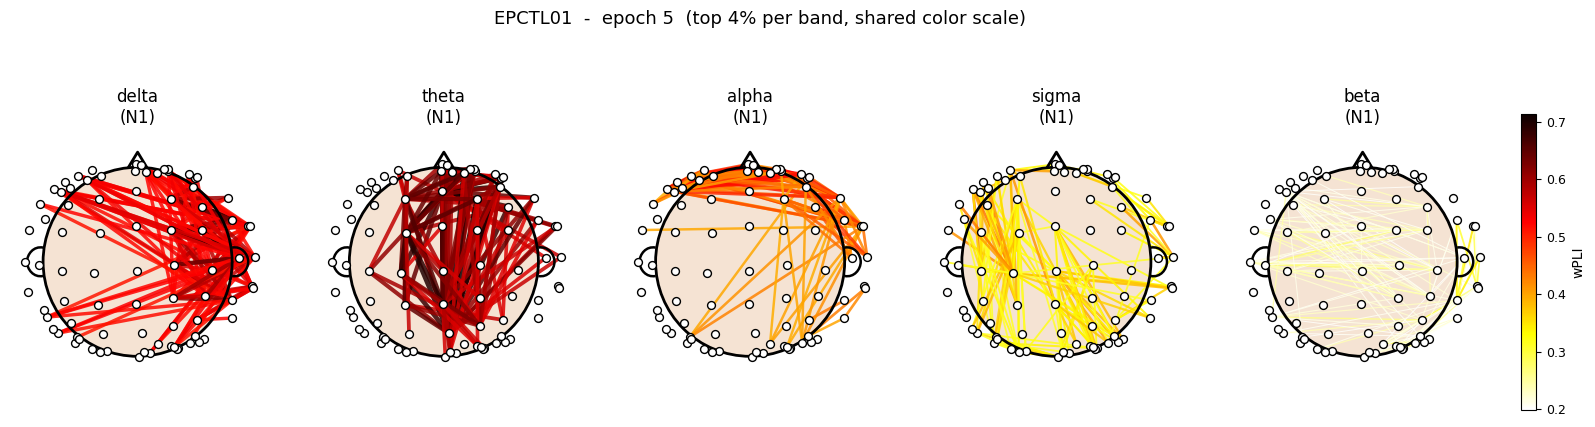

In [2]:
"""
Band-comparison scalp plot for one epoch, with:
  - an anatomically-styled head outline (rounded nose, curved ears, skin tone)
  - a single SHARED color scale across all bands, so darkness/color is
    directly comparable band to band (previously each band had its own
    independent vmin/vmax, so "looks equally dark" didn't mean "equally
    strong" across different subplots)
  - a printed list of the top edges (by channel name, not just position)
    for each band, so any visually striking cluster can be checked against
    real channel identities before trusting it
"""

import re
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Circle, PathPatch, Polygon
from matplotlib.path import Path as MplPath

# ------------------------------------------------------------------
# Settings
# ------------------------------------------------------------------
DATA_ROOT = Path("./anphy_sleep_data")
h5_path   = Path("graphs_output/EPCTL01.h5")
pos_path  = DATA_ROOT / "co-registered_average_positions.pos"

epoch_idx    = 5          # single epoch
top_percent  = 4           # keep strongest N% PER BAND for edge selection
n_top_print  = 10          # how many top edges to print per band
# ------------------------------------------------------------------


def parse_pos_file(pos_path):
    ch_pos = {}
    with open(pos_path, "r") as f:
        lines = f.readlines()
    for line in lines[1:]:
        parts = line.strip().split()
        if len(parts) >= 5:
            name = parts[1]
            x, y, z = map(float, parts[2:5])
            ch_pos[name] = np.array([x, y, z])
    return ch_pos


def normalize(name):
    name = name.lower().strip()
    for s in ["-ref", "_ref", "-avg", "_avg", "-car", "_car"]:
        if name.endswith(s):
            name = name[:-len(s)]
    return re.sub(r'^[\-\+_]+|[\-\+_]+$', '', name)


def _ear_path(x_sign: float) -> MplPath:
    """Rounded ear bump built from two cubic-bezier curves, attached to
    the head outline at (x_sign*1.0, +-0.15)."""
    verts = [
        (x_sign * 1.00,  0.15),
        (x_sign * 1.10,  0.17),
        (x_sign * 1.17,  0.08),
        (x_sign * 1.17,  0.00),
        (x_sign * 1.17, -0.08),
        (x_sign * 1.10, -0.17),
        (x_sign * 1.00, -0.15),
    ]
    codes = [MplPath.MOVETO] + [MplPath.CURVE4] * 6
    return MplPath(verts, codes)


def draw_head(ax):
    """Skin-tone filled head, rounded nose, curved ears."""
    ax.add_patch(Circle((0, 0), 1.0, facecolor="#f5e3d3", edgecolor="none", zorder=0))
    ax.add_patch(Circle((0, 0), 1.0, fill=False, lw=2.0, color="k", zorder=3))

    nose_base_half_width = 0.10
    base_y = np.sqrt(1.0 - nose_base_half_width**2)
    nose = Polygon(
        [(-nose_base_half_width, base_y), (0.0, 1.16), (nose_base_half_width, base_y)],
        closed=False, fill=False, lw=2.0, edgecolor="k",
        joinstyle="round", zorder=3,
    )
    ax.add_patch(nose)

    for x_sign in (-1, 1):
        ax.add_patch(PathPatch(_ear_path(x_sign), fill=False, lw=1.8, color="k", zorder=3))


def print_top_edges(con: np.ndarray, ch_names: list[str], band: str,
                     top_percent: float, n: int = 10) -> None:
    """
    Print the top n edges for this band by channel NAME (not just matrix
    index) -- lets you check whether a visually striking cluster involves
    channels that make anatomical sense together, rather than trusting
    the plot's spatial layout at face value.
    """
    iu_i, iu_j = np.triu_indices_from(con, k=1)
    vals = con[iu_i, iu_j]
    order = np.argsort(vals)[::-1][:n]

    print(f"\n--- {band}: top {n} edges (of the top {top_percent}% used in the plot) ---")
    for rank, idx in enumerate(order, 1):
        i, j = iu_i[idx], iu_j[idx]
        print(f"  {rank:2d}. {ch_names[i]:6s} <-> {ch_names[j]:6s}   wPLI={vals[idx]:.4f}")


# Load
with h5py.File(h5_path, "r") as f:
    bands = list(f.attrs["bands"])
    ch_names = [c.decode() if isinstance(c, bytes) else c for c in f["channel_names"][:]]
    stage = f["stage"][epoch_idx]
    if isinstance(stage, bytes):
        stage = stage.decode()
    band_matrices = {band: f[band][epoch_idx] for band in bands}

ch_pos_raw = parse_pos_file(pos_path)
ch_pos_norm = {normalize(k): v for k, v in ch_pos_raw.items()}

coords_3d = np.array([ch_pos_norm[normalize(n)] for n in ch_names])
xy = coords_3d[:, :2].copy()
xy -= xy.mean(axis=0)
xy *= 1.25 / np.max(np.linalg.norm(xy, axis=1))

# ------------------------------------------------------------------
# Per-band edge selection (which edges to draw), but a SHARED color scale
# across all bands (how dark/intense a drawn edge looks) -- selection
# stays band-specific since raw magnitudes differ intrinsically by band
# (delta is always higher than beta), but color intensity is now globally
# comparable: the same wPLI value looks the same color in every subplot.
# ------------------------------------------------------------------
per_band_thresh = {}
above_thresh_vals = []

for band, con in band_matrices.items():
    triu = con[np.triu_indices_from(con, k=1)]
    thresh = np.percentile(triu, 100 - top_percent)
    per_band_thresh[band] = thresh
    above_thresh_vals.append(triu[triu >= thresh])

all_shown_vals = np.concatenate(above_thresh_vals)
global_vmin = min(per_band_thresh.values())
global_vmax = np.percentile(all_shown_vals, 99.5)
norm = Normalize(vmin=global_vmin, vmax=global_vmax)
cmap = plt.cm.hot_r

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
n_bands = len(bands)
fig, axes = plt.subplots(1, n_bands, figsize=(4.0 * n_bands, 4.8))
if n_bands == 1:
    axes = [axes]

for ax, band in zip(axes, bands):
    con = band_matrices[band]
    thresh = per_band_thresh[band]

    print_top_edges(con, ch_names, band, top_percent, n=n_top_print)

    draw_head(ax)

    for i, j in zip(*np.triu_indices_from(con, k=1)):
        w = con[i, j]
        if w >= thresh:
            ax.plot(
                [xy[i, 0], xy[j, 0]],
                [xy[i, 1], xy[j, 1]],
                color=cmap(norm(w)),
                lw=0.7 + 2.8 * norm(w),
                alpha=0.85,
                zorder=1,
            )

    ax.scatter(xy[:, 0], xy[:, 1], s=32, c="white", edgecolors="k",
               linewidths=1.0, zorder=4)

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{band}\n({stage})", fontsize=12, pad=8)

# ONE shared colorbar for the whole figure instead of one per subplot
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, shrink=0.8)
cbar.set_label("wPLI", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.suptitle(
    f"{h5_path.stem}  -  epoch {epoch_idx}  (top {top_percent}% per band, shared color scale)",
    fontsize=13, y=1.02,
)
plt.show()

In [12]:
from pathlib import Path
from peripheral_channel_check import compare_peripheral_pair_types
import importlib

import peripheral_channel_check
importlib.reload(peripheral_channel_check) 

compare_peripheral_pair_types(Path("graphs_output_before_EMG"), epoch_stride=10)

Checked 28 subject(s), every 10th epoch

--- delta band: three-way edge comparison ---
  both_central     n=  4430670  mean=0.2387  median=0.1992
  one_peripheral   n=  3045634  mean=0.2469  median=0.2065
  both_peripheral  n=   510537  mean=0.2425  median=0.2026
  both_peripheral vs both_central: +0.0039
  one_peripheral  vs both_central: +0.0082
  [OK] no meaningful effect in either peripheral group for this band.

--- theta band: three-way edge comparison ---
  both_central     n=  4430670  mean=0.1675  median=0.1398
  one_peripheral   n=  3045634  mean=0.1726  median=0.1453
  both_peripheral  n=   510537  mean=0.1644  median=0.1384
  both_peripheral vs both_central: -0.0031
  one_peripheral  vs both_central: +0.0052
  [OK] no meaningful effect in either peripheral group for this band.

--- alpha band: three-way edge comparison ---
  both_central     n=  4430670  mean=0.2260  median=0.1836
  one_peripheral   n=  3045634  mean=0.2465  median=0.2026
  both_peripheral  n=   510537  mea

{'delta': {'both_central': array([0.16311477, 0.40973765, 0.0428608 , ..., 0.25503173, 0.06099981,
         0.14790636], dtype=float32),
  'one_peripheral': array([0.08855566, 0.05958733, 0.07744724, ..., 0.00472508, 0.07354692,
         0.03429798], dtype=float32),
  'both_peripheral': array([0.00800781, 0.03671155, 0.05539985, ..., 0.04388631, 0.27084103,
         0.33654237], dtype=float32)},
 'theta': {'both_central': array([0.03841788, 0.30413175, 0.06713127, ..., 0.2523885 , 0.24884945,
         0.12303253], dtype=float32),
  'one_peripheral': array([0.01822747, 0.03901848, 0.06928512, ..., 0.25166854, 0.20388989,
         0.22712982], dtype=float32),
  'both_peripheral': array([0.03128176, 0.11546071, 0.01990446, ..., 0.18305856, 0.17000815,
         0.00737664], dtype=float32)},
 'alpha': {'both_central': array([0.04157249, 0.03922303, 0.06474002, ..., 0.19357008, 0.5145676 ,
         0.4845909 ], dtype=float32),
  'one_peripheral': array([0.03561468, 0.05309338, 0.14121516, ..

To evaluate potential contamination of the sensor-space wPLI networks, we performed targeted robustness checks focused on the spatial and spectral pattern of the observed connectivity. Edge-enrichment analyses revealed that elevated connectivity was concentrated in the beta band and predominantly on edges linking two peripheral electrodes. Subsequent regression of EOG signals did not account for this pattern, and EMG regression produced only minimal attenuation of the peripheral beta inflation. Lower-frequency bands (delta–sigma) showed no comparable peripheral enrichment. Because these checks directly tested the most plausible artifact sources (ocular and myogenic) against the specific topography and frequency range of the effect, and because the remaining bands and non-peripheral edges remained stable, the main analyses were retained on the full network. A sensitivity analysis excluding both-peripheral beta edges was used to confirm that the primary graph-theoretic findings were not driven by this spatially restricted subset.

In [ ]:
#EOG contamination check:

from pathlib import Path
from eog_check import run_frontal_check
import importlib

import eog_check
importlib.reload(eog_check) 

run_frontal_check(Path("graphs_output_before_EMG"), bands=("delta", "theta", "alpha", "sigma", "beta"))

Checking 28 subject(s), top 4% edges, every 10th epoch, bands=('delta', 'theta', 'alpha', 'sigma', 'beta')...

Band       Baseline   Observed   Enrichment
--------------------------------------------
delta        18.5%     22.4%        1.22x
theta        18.5%     20.3%        1.10x
alpha        18.5%     22.1%        1.20x
sigma        18.5%     27.0%        1.47x
beta         18.5%     11.8%        0.64x

A ratio near 1.0x means frontal channels show up in the strongest edges about as often as chance predicts -- no evidence of EOG concentration, supporting leaving EOG uncorrected. A ratio well above 1.0x would be real evidence worth investigating before deciding.


"No substantial enrichment of frontal channels among the strongest wPLI edges was observed. These results do not provide evidence that EOG contamination is a dominant contributor to the strongest connectivity patterns in this dataset. Stage-specific analyses (especially REM) may still be useful if EOG contamination remains a concern."

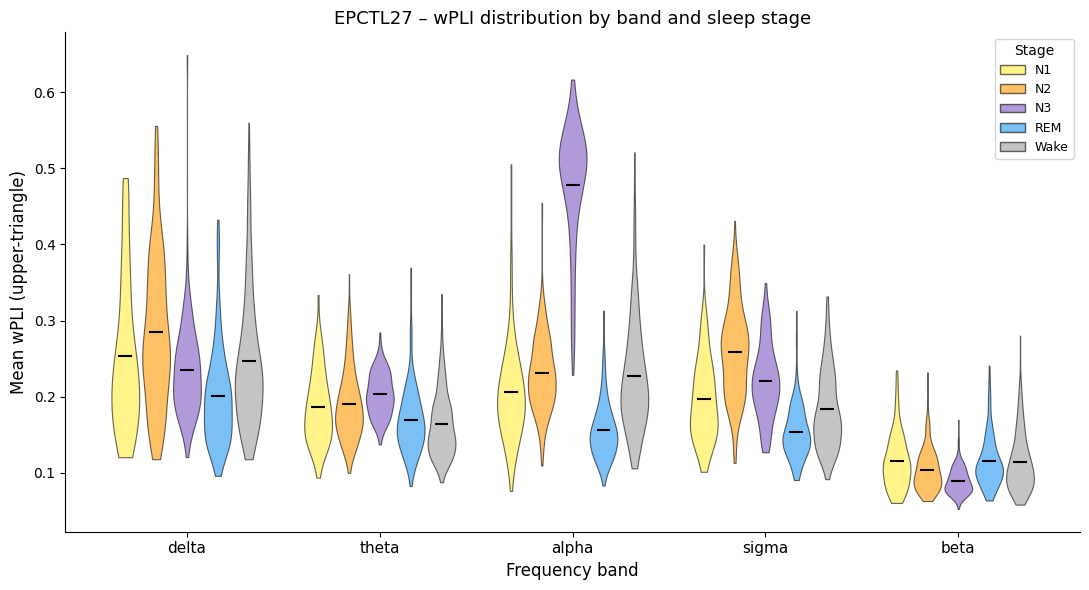

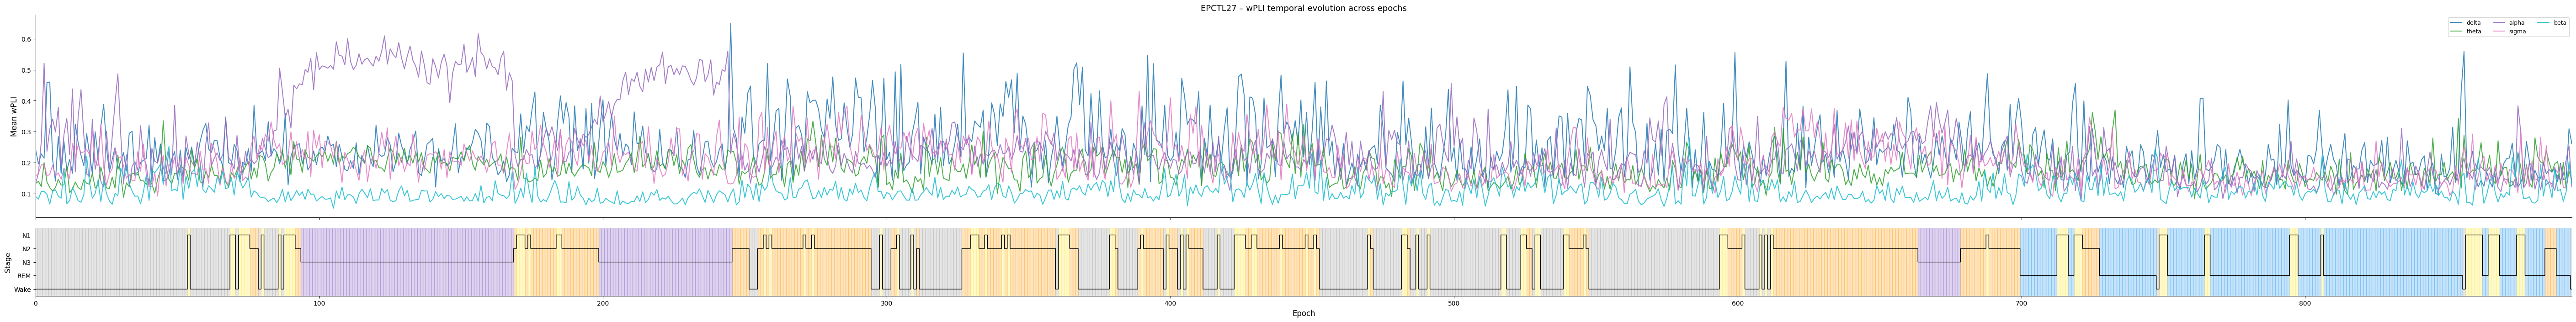

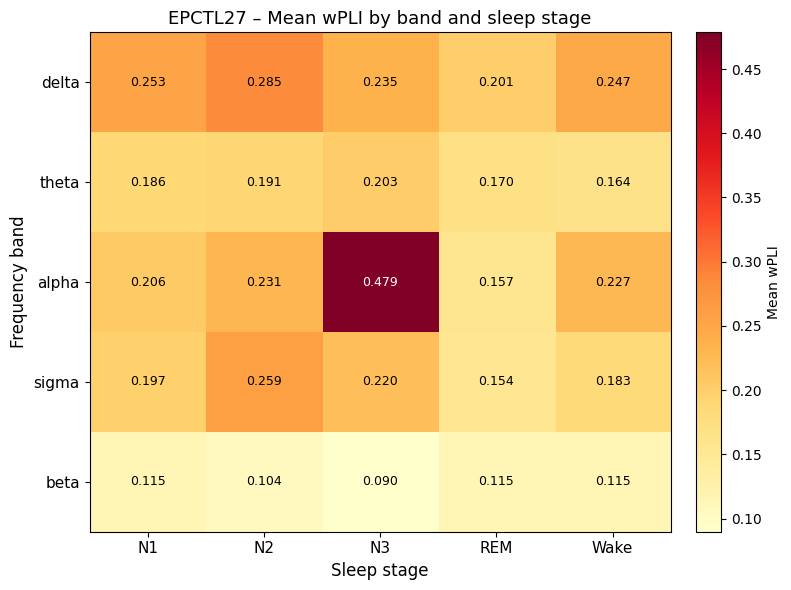

In [11]:
import re
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from collections import defaultdict


# ------------------------------------------------------------------
# Settings
# ------------------------------------------------------------------
h5_path = Path("graphs_output/EPCTL27.h5")
# ------------------------------------------------------------------


def normalize(name):
    name = name.lower().strip()
    for s in ["-ref", "_ref", "-avg", "_avg", "-car", "_car"]:
        if name.endswith(s):
            name = name[:-len(s)]
    return re.sub(r'^[\-\+_]+|[\-\+_]+$', '', name)


# ------------------------------------------------------------------
# Load everything
# ------------------------------------------------------------------
with h5py.File(h5_path, "r") as f:
    bands = list(f.attrs["bands"])
    ch_names = [c.decode() if isinstance(c, bytes) else c for c in f["channel_names"][:]]
    stages_raw = f["stage"][:]
    stages = [s.decode() if isinstance(s, bytes) else s for s in stages_raw]
    n_epochs = len(stages)

    # band_matrices[band]  ->  array of shape (n_epochs, n_ch, n_ch)
    band_matrices = {band: f[band][:] for band in bands}

n_ch = len(ch_names)
triu_idx = np.triu_indices(n_ch, k=1)

# Unique sleep stages, sorted for consistent ordering (N3 before REM etc.
# is handled by the custom order below if present)
stage_order_pref = ["W", "N1", "N2", "N3", "REM"]
unique_stages = sorted(set(stages), key=lambda s: stage_order_pref.index(s)
                      if s in stage_order_pref else len(stage_order_pref))

# Colour per stage
stage_colors = {
    "W":    "#4CAF50",
    "N1":   "#FFEB3B",
    "N2":   "#FF9800",
    "N3":   "#7E57C2",
    "REM":  "#2196F3",
}
default_color = "#9E9E9E"


# ------------------------------------------------------------------
# Per-epoch mean wPLI (upper-triangle mean of each connectivity matrix)
# ------------------------------------------------------------------
mean_wpli = {}          # mean_wpli[band][epoch] = scalar
for band in bands:
    mats = band_matrices[band]              # (n_epochs, n_ch, n_ch)
    triu_vals = mats[:, triu_idx[0], triu_idx[1]]   # (n_epochs, n_triu)
    mean_wpli[band] = triu_vals.mean(axis=1)


# ==================================================================
# PLOT 1 – Violin / box: wPLI distribution per band, split by stage
# ==================================================================
fig1, ax1 = plt.subplots(figsize=(max(10, 2.2 * len(bands)), 6))

n_bands = len(bands)
n_stages = len(unique_stages)
violin_width = 0.8 / n_stages           # width of each violin
x_offsets = np.linspace(-0.4 + violin_width/2,
                         0.4 - violin_width/2, n_stages)

for b_idx, band in enumerate(bands):
    for s_idx, stage in enumerate(unique_stages):
        epoch_mask = np.array([s == stage for s in stages])
        vals = mean_wpli[band][epoch_mask]
        if len(vals) < 2:
            continue

        pos = b_idx + x_offsets[s_idx]
        parts = ax1.violinplot(vals, positions=[pos],
                              widths=violin_width * 0.9,
                              showmeans=True, showmedians=False,
                              showextrema=False)
        color = stage_colors.get(stage, default_color)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
            pc.set_edgecolor("k")
            pc.set_linewidth(0.8)
        parts["cmeans"].set_color("k")
        parts["cmeans"].set_linewidth(1.5)

ax1.set_xticks(range(n_bands))
ax1.set_xticklabels(bands, fontsize=11)
ax1.set_xlabel("Frequency band", fontsize=12)
ax1.set_ylabel("Mean wPLI (upper-triangle)", fontsize=12)
ax1.set_title(f"{h5_path.stem} – wPLI distribution by band and sleep stage", fontsize=13)

# Legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=stage_colors.get(s, default_color), alpha=0.6,
                 edgecolor="k", label=s) for s in unique_stages]
ax1.legend(handles=handles, title="Stage", loc="upper right", fontsize=9)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.tight_layout()


# ==================================================================
# PLOT 2 – Temporal evolution + hypnogram
# ==================================================================
fig2 = plt.figure(figsize=(max(12, 0.08 * n_epochs), 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

# --- top: mean wPLI per band across epochs ---
ax_top = fig2.add_subplot(gs[0])
cmap_lines = plt.cm.tab10(np.linspace(0, 0.9, n_bands))

for b_idx, band in enumerate(bands):
    ax_top.plot(range(n_epochs), mean_wpli[band],
                color=cmap_lines[b_idx], lw=1.4, label=band, alpha=0.85)

ax_top.set_ylabel("Mean wPLI", fontsize=12)
ax_top.set_title(f"{h5_path.stem} – wPLI temporal evolution across epochs", fontsize=13)
ax_top.legend(loc="upper right", fontsize=9, ncol=min(n_bands, 3))
ax_top.set_xlim(0, n_epochs - 1)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.tick_params(labelbottom=False)

# --- bottom: hypnogram (sleep stage per epoch) ---
ax_hyp = fig2.add_subplot(gs[1], sharex=ax_top)

stage_y = {s: i for i, s in enumerate(unique_stages)}
y_vals = [stage_y[s] for s in stages]

# Draw the hypnogram as a step plot
ax_hyp.step(range(n_epochs), y_vals, where="mid", color="k", lw=1.0)

# Colour-shade each epoch by stage
for ep_idx, stage in enumerate(stages):
    color = stage_colors.get(stage, default_color)
    ax_hyp.axvspan(ep_idx - 0.5, ep_idx + 0.5, color=color, alpha=0.25)

ax_hyp.set_yticks(range(len(unique_stages)))
ax_hyp.set_yticklabels(unique_stages, fontsize=10)
ax_hyp.set_xlabel("Epoch", fontsize=12)
ax_hyp.set_ylabel("Stage", fontsize=11)
ax_hyp.set_ylim(-0.5, len(unique_stages) - 0.5)
ax_hyp.invert_yaxis()
ax_hyp.spines["top"].set_visible(False)
ax_hyp.spines["right"].set_visible(False)

#plt.tight_layout()


# ==================================================================
# PLOT 3 – Heatmap: mean wPLI for each (band × stage)
# ==================================================================
heat = np.full((len(bands), len(unique_stages)), np.nan)

for b_idx, band in enumerate(bands):
    for s_idx, stage in enumerate(unique_stages):
        epoch_mask = np.array([s == stage for s in stages])
        if epoch_mask.sum() == 0:
            continue
        heat[b_idx, s_idx] = mean_wpli[band][epoch_mask].mean()

fig3, ax3 = plt.subplots(figsize=(max(6, 1.2 * len(unique_stages) + 2),
                                max(4, 0.8 * n_bands + 2)))
im = ax3.imshow(heat, aspect="auto", cmap="YlOrRd", interpolation="nearest")

ax3.set_xticks(range(len(unique_stages)))
ax3.set_xticklabels(unique_stages, fontsize=11)
ax3.set_yticks(range(n_bands))
ax3.set_yticklabels(bands, fontsize=11)
ax3.set_xlabel("Sleep stage", fontsize=12)
ax3.set_ylabel("Frequency band", fontsize=12)
ax3.set_title(f"{h5_path.stem} – Mean wPLI by band and sleep stage", fontsize=13)

# Annotate cells
for b_idx in range(n_bands):
    for s_idx in range(len(unique_stages)):
        val = heat[b_idx, s_idx]
        if np.isnan(val):
            continue
        text_color = "white" if val > np.nanmax(heat) * 0.6 else "black"
        ax3.text(s_idx, b_idx, f"{val:.3f}", ha="center", va="center",
                 fontsize=9, color=text_color)

cbar3 = fig3.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label("Mean wPLI", fontsize=10)

plt.tight_layout()

plt.show()

Found 28 files


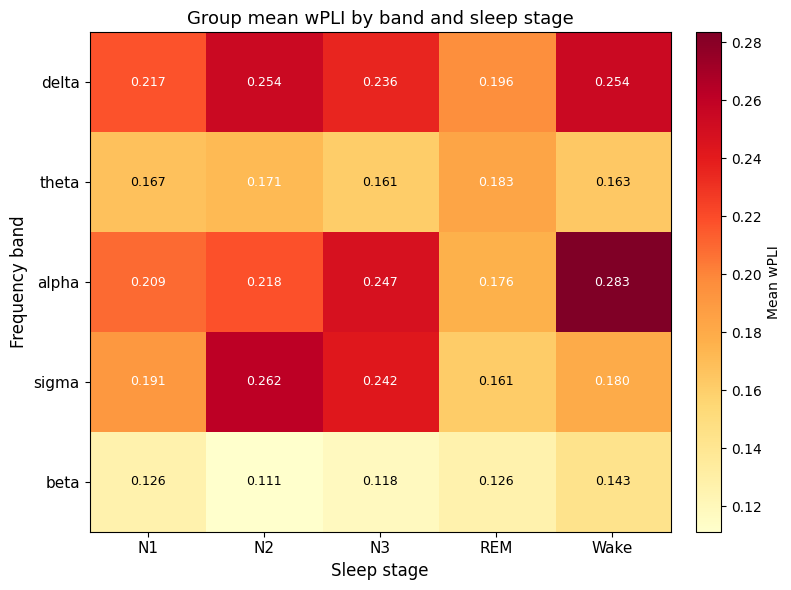

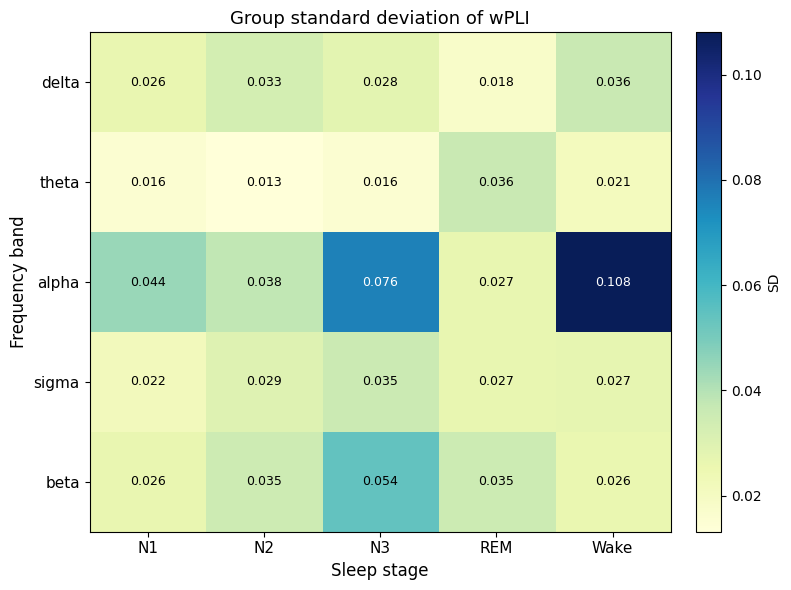

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# List of subject files
# ------------------------------------------------------------------
data_dir = Path("graphs_output")
h5_paths = sorted(data_dir.glob("*.h5"))

print(f"Found {len(h5_paths)} files")

# ------------------------------------------------------------------
# Helper: compute subject-level heat matrix (band x stage)
# ------------------------------------------------------------------
def subject_heat(h5_path):
    with h5py.File(h5_path, "r") as f:
        bands = list(f.attrs["bands"])
        stages_raw = f["stage"][:]
        stages = [s.decode() if isinstance(s, bytes) else s for s in stages_raw]

        n_epochs = len(stages)

        # Connectivity matrices per band
        band_matrices = {band: f[band][:] for band in bands}

    # Unique stages in preferred order
    stage_order_pref = ["W", "N1", "N2", "N3", "REM"]
    unique_stages = sorted(set(stages), key=lambda s: stage_order_pref.index(s)
                           if s in stage_order_pref else len(stage_order_pref))

    # Compute mean-wPLI per epoch per band
    n_ch = band_matrices[bands[0]].shape[1]
    triu_idx = np.triu_indices(n_ch, k=1)

    mean_wpli = {}
    for band in bands:
        mats = band_matrices[band]              # (n_epochs, n_ch, n_ch)
        triu_vals = mats[:, triu_idx[0], triu_idx[1]]  # (n_epochs, n_triu)
        mean_wpli[band] = triu_vals.mean(axis=1)

    # Heat matrix: band x stage
    heat = np.full((len(bands), len(unique_stages)), np.nan)
    for b_idx, band in enumerate(bands):
        for s_idx, stage in enumerate(unique_stages):
            epoch_mask = np.array([s == stage for s in stages])
            if epoch_mask.sum() == 0:
                continue
            heat[b_idx, s_idx] = mean_wpli[band][epoch_mask].mean()

    return bands, unique_stages, heat

# ------------------------------------------------------------------
# Compute heat per subject and stack
# ------------------------------------------------------------------
subject_heats = []
for p in h5_paths:
    bands, unique_stages, heat = subject_heat(p)
    subject_heats.append(heat)

subject_heats = np.stack(subject_heats, axis=0)   # (n_subjects, n_bands, n_stages)

# Group-level statistics
group_mean = np.nanmean(subject_heats, axis=0)    # (n_bands, n_stages)
group_sd   = np.nanstd(subject_heats, axis=0, ddof=1)
n_subj_eff = np.sum(~np.isnan(subject_heats), axis=0)  # effective N per cell
group_se   = group_sd / np.sqrt(n_subj_eff)      # standard error of the mean

# ------------------------------------------------------------------
# Plot 1: group-mean heatmap
# ------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(max(6, 1.2 * len(unique_stages) + 2),
                                  max(4, 0.8 * len(bands) + 2)))
im1 = ax1.imshow(group_mean, aspect="auto", cmap="YlOrRd", interpolation="nearest")

ax1.set_xticks(range(len(unique_stages)))
ax1.set_xticklabels(unique_stages, fontsize=11)
ax1.set_yticks(range(len(bands)))
ax1.set_yticklabels(bands, fontsize=11)
ax1.set_xlabel("Sleep stage", fontsize=12)
ax1.set_ylabel("Frequency band", fontsize=12)
ax1.set_title("Group mean wPLI by band and sleep stage", fontsize=13)

for b_idx in range(len(bands)):
    for s_idx in range(len(unique_stages)):
        val = group_mean[b_idx, s_idx]
        if np.isnan(val):
            continue
        text_color = "white" if val > np.nanmax(group_mean) * 0.6 else "black"
        ax1.text(s_idx, b_idx, f"{val:.3f}", ha="center", va="center",
                 fontsize=9, color=text_color)

cbar1 = fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Mean wPLI", fontsize=10)

plt.tight_layout()

# ------------------------------------------------------------------
# Plot 2: SD or SE heatmap (choose one)
# ------------------------------------------------------------------
# Choose what you want to visualize: SD (variability) or SE (precision)
stat_to_show = "SD"   # or "SE"

stat_matrix = group_sd if stat_to_show == "SD" else group_se
title_suffix = "standard deviation" if stat_to_show == "SD" else "standard error (SEM)"

fig2, ax2 = plt.subplots(figsize=(max(6, 1.2 * len(unique_stages) + 2),
                                  max(4, 0.8 * len(bands) + 2)))
im2 = ax2.imshow(stat_matrix, aspect="auto", cmap="YlGnBu", interpolation="nearest")

ax2.set_xticks(range(len(unique_stages)))
ax2.set_xticklabels(unique_stages, fontsize=11)
ax2.set_yticks(range(len(bands)))
ax2.set_yticklabels(bands, fontsize=11)
ax2.set_xlabel("Sleep stage", fontsize=12)
ax2.set_ylabel("Frequency band", fontsize=12)
ax2.set_title(f"Group {title_suffix} of wPLI", fontsize=13)

for b_idx in range(len(bands)):
    for s_idx in range(len(unique_stages)):
        val = stat_matrix[b_idx, s_idx]
        if np.isnan(val):
            continue
        text_color = "white" if val > np.nanmax(stat_matrix) * 0.6 else "black"
        ax2.text(s_idx, b_idx, f"{val:.3f}", ha="center", va="center",
                 fontsize=9, color=text_color)

cbar2 = fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("SD" if stat_to_show == "SD" else "SE", fontsize=10)

plt.tight_layout()
plt.show()

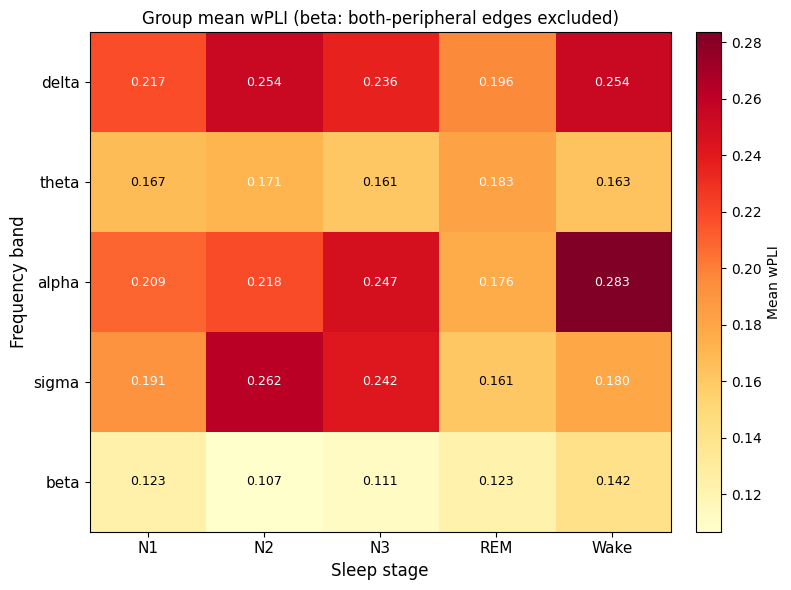

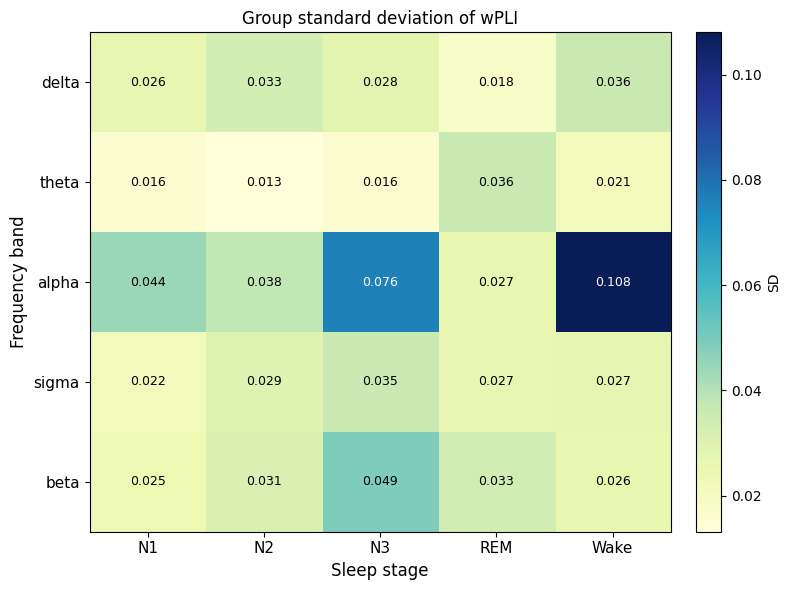

In [ ]:
#SAME HEATMAP BUT WITH THE BOTH-PERIPHERAL CHANNEL CORRECTION IN THE BETA BAND OF ALL THE SUBJECTS
from peripheral_channel_check import PERIPHERAL_CHANNELS

data_dir = Path("graphs_output")
h5_paths = sorted(data_dir.glob("*.h5"))

# Bands where your compare_peripheral_pair_types() run showed a real,
# concentrated both-peripheral effect (currently just beta)
CORRECT_BANDS = {"beta"}

def both_peripheral_mask(ch_names, triu_idx, peripheral=PERIPHERAL_CHANNELS):
    is_periph = np.array([name in peripheral for name in ch_names])
    a, b = triu_idx
    return is_periph[a] & is_periph[b]

def subject_heat(h5_path):
    with h5py.File(h5_path, "r") as f:
        bands = list(f.attrs["bands"])
        ch_names = [c.decode() if isinstance(c, bytes) else c for c in f["channel_names"][:]]
        stages_raw = f["stage"][:]
        stages = [s.decode() if isinstance(s, bytes) else s for s in stages_raw]
        band_matrices = {band: f[band][:] for band in bands}

    n_ch = len(ch_names)
    triu_idx = np.triu_indices(n_ch, k=1)
    both_periph = both_peripheral_mask(ch_names, triu_idx)

    stage_order_pref = ["W", "N1", "N2", "N3", "REM"]
    unique_stages = sorted(set(stages), key=lambda s: stage_order_pref.index(s)
                           if s in stage_order_pref else len(stage_order_pref))

    mean_wpli = {}
    for band in bands:
        mats = band_matrices[band]                     # (n_epochs, n_ch, n_ch)
        triu_vals = mats[:, triu_idx[0], triu_idx[1]]   # (n_epochs, n_triu)

        if band in CORRECT_BANDS:
            keep = ~both_periph                          # drop both-peripheral edges only
            triu_vals = triu_vals[:, keep]

        mean_wpli[band] = triu_vals.mean(axis=1)

    heat = np.full((len(bands), len(unique_stages)), np.nan)
    for b_idx, band in enumerate(bands):
        for s_idx, stage in enumerate(unique_stages):
            epoch_mask = np.array([s == stage for s in stages])
            if epoch_mask.sum() == 0:
                continue
            heat[b_idx, s_idx] = mean_wpli[band][epoch_mask].mean()

    return bands, unique_stages, heat

subject_heats = []
for p in h5_paths:
    bands, unique_stages, heat = subject_heat(p)
    subject_heats.append(heat)

subject_heats = np.stack(subject_heats, axis=0)          # (n_subjects, n_bands, n_stages)
group_mean = np.nanmean(subject_heats, axis=0)
group_sd   = np.nanstd(subject_heats, axis=0, ddof=1)
n_subj_eff = np.sum(~np.isnan(subject_heats), axis=0)
group_se   = group_sd / np.sqrt(n_subj_eff)

fig1, ax1 = plt.subplots(figsize=(max(6, 1.2 * len(unique_stages) + 2),
                                  max(4, 0.8 * len(bands) + 2)))
im1 = ax1.imshow(group_mean, aspect="auto", cmap="YlOrRd", interpolation="nearest")

ax1.set_xticks(range(len(unique_stages))); ax1.set_xticklabels(unique_stages, fontsize=11)
ax1.set_yticks(range(len(bands))); ax1.set_yticklabels(bands, fontsize=11)
ax1.set_xlabel("Sleep stage", fontsize=12); ax1.set_ylabel("Frequency band", fontsize=12)
ax1.set_title("Group mean wPLI (beta: both-peripheral edges excluded)", fontsize=12)

for b_idx in range(len(bands)):
    for s_idx in range(len(unique_stages)):
        val = group_mean[b_idx, s_idx]
        if np.isnan(val): continue
        tc = "white" if val > np.nanmax(group_mean) * 0.6 else "black"
        ax1.text(s_idx, b_idx, f"{val:.3f}", ha="center", va="center", fontsize=9, color=tc)

fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04).set_label("Mean wPLI", fontsize=10)
plt.tight_layout()

stat_to_show = "SD"   # or "SE"
stat_matrix = group_sd if stat_to_show == "SD" else group_se
title_suffix = "standard deviation" if stat_to_show == "SD" else "standard error (SEM)"

fig2, ax2 = plt.subplots(figsize=(max(6, 1.2 * len(unique_stages) + 2),
                                  max(4, 0.8 * len(bands) + 2)))
im2 = ax2.imshow(stat_matrix, aspect="auto", cmap="YlGnBu", interpolation="nearest")

ax2.set_xticks(range(len(unique_stages))); ax2.set_xticklabels(unique_stages, fontsize=11)
ax2.set_yticks(range(len(bands))); ax2.set_yticklabels(bands, fontsize=11)
ax2.set_xlabel("Sleep stage", fontsize=12); ax2.set_ylabel("Frequency band", fontsize=12)
ax2.set_title(f"Group {title_suffix} of wPLI", fontsize=12)

for b_idx in range(len(bands)):
    for s_idx in range(len(unique_stages)):
        val = stat_matrix[b_idx, s_idx]
        if np.isnan(val): continue
        tc = "white" if val > np.nanmax(stat_matrix) * 0.6 else "black"
        ax2.text(s_idx, b_idx, f"{val:.3f}", ha="center", va="center", fontsize=9, color=tc)

fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04).set_label(stat_to_show, fontsize=10)
plt.tight_layout()
plt.show()

A few things stand out:

Delta: Highest mean in N2/N3 and Wake, with a dip in REM. Strong slow‑wave connectivity in N2/N3 is expected; the Wake elevation may reflect different connectivity structure, artifacts, or the way wPLI emphasizes phase‑lagged interactions rather than pure power.

Theta: Fairly flat with a slight bump in REM. That’s not implausible; REM often shows more theta activity, and connectivity changes can be modest.

Alpha: Clear increase from N1 → N2 → N3, then lowest in REM and highest in Wake. Elevated alpha connectivity in deeper NREM can map onto synchronous thalamo‑cortical activity; high alpha in Wake is also reasonable.

Sigma: Peak in N2/N3, much lower in REM/Wake. That’s exactly what you’d expect from spindle‑band connectivity (N2/N3 are spindle‑rich).

Beta: Low across all sleep stages with a modest rise in Wake. Beta is typically associated with wakefulness and cognitive/motor activity, so this directionally fits.

So as a group mean wPLI (across 28 subjects) by band × stage, this pattern is physiologically credible and matches a lot of classic sleep EEG intuitions.